In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Tractor-Sales.csv")

In [3]:
df.head()

,Month-Year,Number of Tractor Sold
0,Jan-03,141
1,Feb-03,157
2,Mar-03,185
3,Apr-03,199
4,May-03,203


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Month-Year              144 non-null    str  
 1   Number of Tractor Sold  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.2 KB


In [5]:
df.describe()

,Number of Tractor Sold
count,144.000000
mean,389.694444
std,171.500016
min,138.000000
25%,248.500000
50%,369.000000
75%,509.250000
max,871.000000


In [6]:
dates = pd.date_range(start = "2003-01-01", freq="MS", periods= len(df))
dates

DatetimeIndex(['2003-01-01', '2003-02-01', '2003-03-01', '2003-04-01',
               '2003-05-01', '2003-06-01', '2003-07-01', '2003-08-01',
               '2003-09-01', '2003-10-01',
               ...
               '2014-03-01', '2014-04-01', '2014-05-01', '2014-06-01',
               '2014-07-01', '2014-08-01', '2014-09-01', '2014-10-01',
               '2014-11-01', '2014-12-01'],
              dtype='datetime64[us]', length=144, freq='MS')

In [7]:
#Breakink down into INDIVIDUAL COMPONENTS (Year, Months, and Date)
import calendar
df["Months"] = dates.month
df["Months"] = df["Months"].apply(lambda x: calendar.month_abbr[x]) #Because of this line we will get(Jan, Feb) instead of (1st, 2nd) month

df["Year"] = dates.year

In [8]:
df.head()

,Month-Year,Number of Tractor Sold,Months,Year
0,Jan-03,141,Jan,2003
1,Feb-03,157,Feb,2003
2,Mar-03,185,Mar,2003
3,Apr-03,199,Apr,2003
4,May-03,203,May,2003


In [9]:
df.drop(["Month-Year"], axis=1, inplace= True)

In [10]:
df.head()

,Number of Tractor Sold,Months,Year
0,141,Jan,2003
1,157,Feb,2003
2,185,Mar,2003
3,199,Apr,2003
4,203,May,2003


In [11]:
#Renaming
df.rename(columns = {"Number of Tractor Sold":"Tractor-Sales"}, inplace= True)

In [12]:
df.head()

,Tractor-Sales,Months,Year
0,141,Jan,2003
1,157,Feb,2003
2,185,Mar,2003
3,199,Apr,2003
4,203,May,2003


In [13]:
#Indexing
df.set_index(dates, inplace=True)
df.head()

,Tractor-Sales,Months,Year
2003-01-01,141,Jan,2003
2003-02-01,157,Feb,2003
2003-03-01,185,Mar,2003
2003-04-01,199,Apr,2003
2003-05-01,203,May,2003


Text(0, 0.5, 'Tractor Sales')

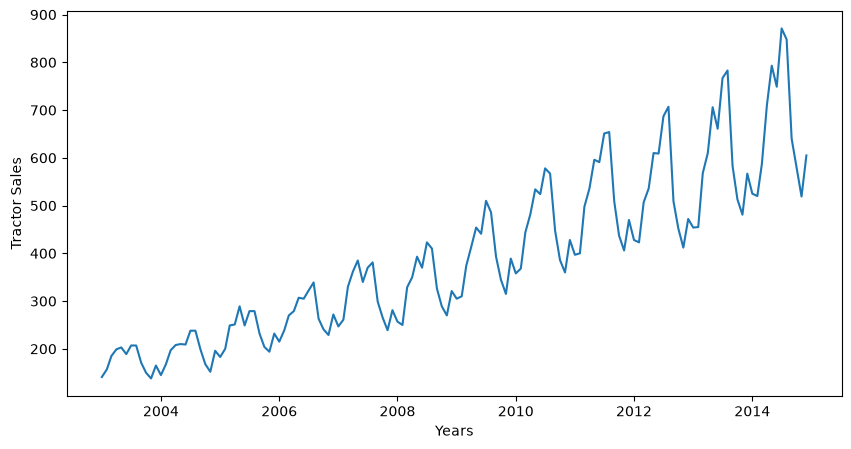

In [14]:
#PLOT
df_ts= df["Tractor-Sales"]
plt.figure(figsize=(10,5))
plt.plot(df_ts)
plt.xlabel("Years")
plt.ylabel("Tractor Sales")

Creating PIOVT TABLE for Monthly Basis

In [15]:
monthly_sales = pd.pivot_table(df, values= "Tractor-Sales",columns="Year",index="Months")
monthly_sales

Year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
Months,,,,,,,,,,,,
Apr,199.0,208.0,251.0,279.0,362.0,350.0,414.0,482.0,536.0,536.0,610.0,710.0
Aug,207.0,238.0,279.0,339.0,381.0,410.0,486.0,567.0,654.0,707.0,783.0,848.0
Dec,165.0,196.0,232.0,272.0,281.0,321.0,389.0,428.0,470.0,472.0,567.0,605.0
Feb,157.0,168.0,200.0,239.0,261.0,250.0,310.0,368.0,400.0,423.0,455.0,520.0
Jan,141.0,145.0,183.0,215.0,247.0,257.0,305.0,358.0,397.0,428.0,454.0,525.0
Jul,207.0,238.0,279.0,322.0,370.0,423.0,510.0,578.0,651.0,687.0,767.0,871.0
Jun,189.0,209.0,249.0,305.0,340.0,370.0,441.0,524.0,591.0,609.0,661.0,749.0
Mar,185.0,197.0,249.0,270.0,330.0,329.0,374.0,444.0,498.0,507.0,568.0,587.0
May,203.0,210.0,289.0,307.0,385.0,393.0,454.0,534.0,596.0,610.0,706.0,793.0


In [16]:
#Re-Index to get it properly ROWwise
monthly_sales= monthly_sales.reindex(index = ['Jan','Feb','Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
monthly_sales

Year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
Months,,,,,,,,,,,,
Jan,141.0,145.0,183.0,215.0,247.0,257.0,305.0,358.0,397.0,428.0,454.0,525.0
Feb,157.0,168.0,200.0,239.0,261.0,250.0,310.0,368.0,400.0,423.0,455.0,520.0
Mar,185.0,197.0,249.0,270.0,330.0,329.0,374.0,444.0,498.0,507.0,568.0,587.0
Apr,199.0,208.0,251.0,279.0,362.0,350.0,414.0,482.0,536.0,536.0,610.0,710.0
May,203.0,210.0,289.0,307.0,385.0,393.0,454.0,534.0,596.0,610.0,706.0,793.0
Jun,189.0,209.0,249.0,305.0,340.0,370.0,441.0,524.0,591.0,609.0,661.0,749.0
Jul,207.0,238.0,279.0,322.0,370.0,423.0,510.0,578.0,651.0,687.0,767.0,871.0
Aug,207.0,238.0,279.0,339.0,381.0,410.0,486.0,567.0,654.0,707.0,783.0,848.0
Sep,171.0,199.0,232.0,263.0,299.0,326.0,393.0,447.0,509.0,509.0,583.0,640.0


<Axes: xlabel='Months'>

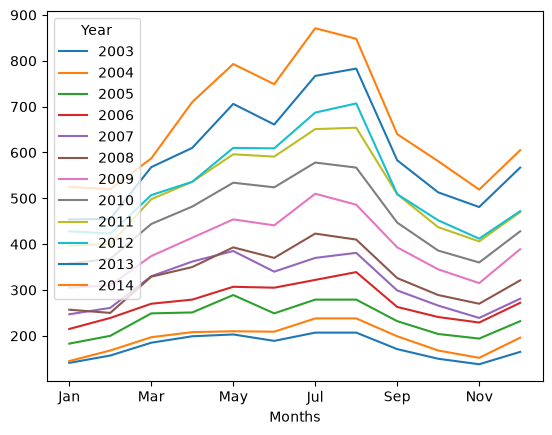

In [17]:
monthly_sales.plot()

# Making yearly data and ploting it to check year patterns Using BOX PLOT

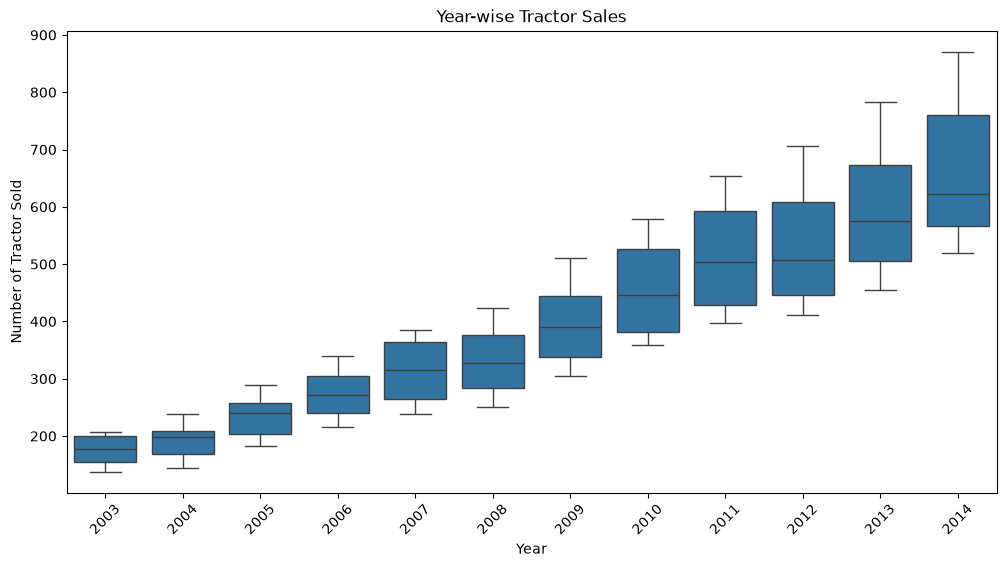

In [18]:
# Year-wise tractor sales distribution

plt.figure(figsize=(12, 6))

sns.boxplot(
    x="Year",
    y="Tractor-Sales",
    data=df
)

plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Number of Tractor Sold")
plt.title("Year-wise Tractor Sales")

plt.show()

Check monthly seasonality

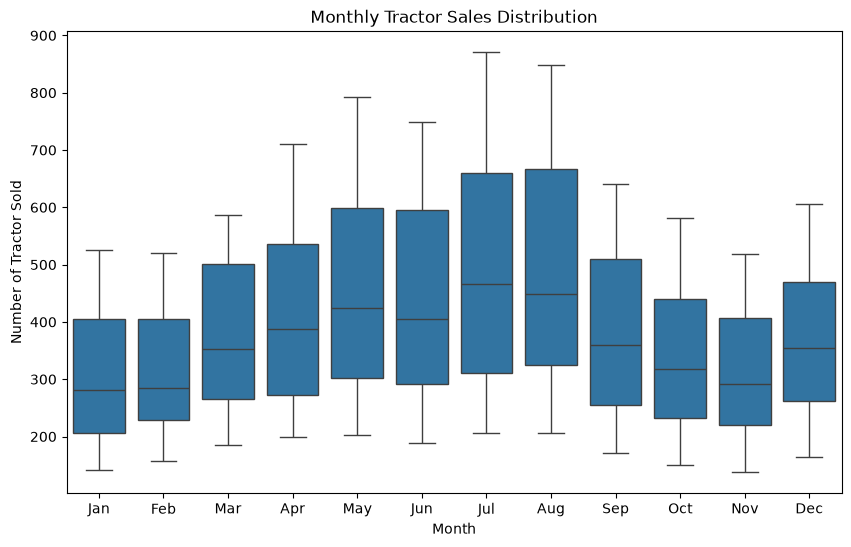

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Months",
    y="Tractor-Sales",
    data=df
)

plt.xlabel("Month")
plt.ylabel("Number of Tractor Sold")
plt.title("Monthly Tractor Sales Distribution")

plt.show()

In [20]:
df["Month_Number"] = df.index.month

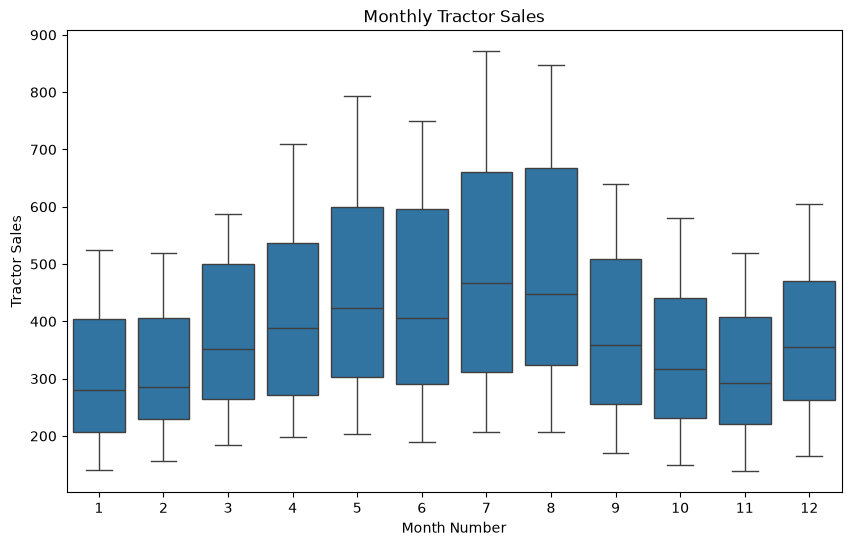

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Month_Number",
    y="Tractor-Sales",
    data=df
)

plt.xlabel("Month Number")
plt.ylabel("Tractor Sales")
plt.title("Monthly Tractor Sales")

plt.show()

## Feature Engineering

In [22]:
df["Month_Number"] = df.index.month
df["Year_Number"] = df.index.year

df["Time_Index"] = np.arange(len(df))

df.head()

,Tractor-Sales,Months,Year,Month_Number,Year_Number,Time_Index
2003-01-01,141,Jan,2003,1,2003,0
2003-02-01,157,Feb,2003,2,2003,1
2003-03-01,185,Mar,2003,3,2003,2
2003-04-01,199,Apr,2003,4,2003,3
2003-05-01,203,May,2003,5,2003,4


In [23]:
df["Lag_1"] = df["Tractor-Sales"].shift(1)
df["Lag_2"] = df["Tractor-Sales"].shift(2)
df["Lag_3"] = df["Tractor-Sales"].shift(3)
df["Lag_12"] = df["Tractor-Sales"].shift(12)

df.head(15)

,Tractor-Sales,Months,Year,Month_Number,Year_Number,Time_Index,Lag_1,Lag_2,Lag_3,Lag_12
2003-01-01,141,Jan,2003,1,2003,0,NaN,NaN,NaN,NaN
2003-02-01,157,Feb,2003,2,2003,1,141.0,NaN,NaN,NaN
2003-03-01,185,Mar,2003,3,2003,2,157.0,141.0,NaN,NaN
2003-04-01,199,Apr,2003,4,2003,3,185.0,157.0,141.0,NaN
2003-05-01,203,May,2003,5,2003,4,199.0,185.0,157.0,NaN
2003-06-01,189,Jun,2003,6,2003,5,203.0,199.0,185.0,NaN
2003-07-01,207,Jul,2003,7,2003,6,189.0,203.0,199.0,NaN
2003-08-01,207,Aug,2003,8,2003,7,207.0,189.0,203.0,NaN
2003-09-01,171,Sep,2003,9,2003,8,207.0,207.0,189.0,NaN
2003-10-01,150,Oct,2003,10,2003,9,171.0,207.0,207.0,NaN


In [24]:
df.isnull().sum()

Tractor-Sales     0
Months            0
Year              0
Month_Number      0
Year_Number       0
Time_Index        0
Lag_1             1
Lag_2             2
Lag_3             3
Lag_12           12
dtype: int64

In [25]:
df.dropna(inplace=True)

In [26]:
df.isnull().sum()

Tractor-Sales    0
Months           0
Year             0
Month_Number     0
Year_Number      0
Time_Index       0
Lag_1            0
Lag_2            0
Lag_3            0
Lag_12           0
dtype: int64

Create rolling features

In [27]:
df["Rolling_Mean_3"] = (
    df["Tractor-Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df["Rolling_Mean_6"] = (
    df["Tractor-Sales"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df.head(15)

,Tractor-Sales,Months,Year,Month_Number,Year_Number,Time_Index,Lag_1,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Rolling_Mean_6
2004-01-01,145,Jan,2004,1,2004,12,165.0,138.0,150.0,141.0,NaN,NaN
2004-02-01,168,Feb,2004,2,2004,13,145.0,165.0,138.0,157.0,NaN,NaN
2004-03-01,197,Mar,2004,3,2004,14,168.0,145.0,165.0,185.0,NaN,NaN
2004-04-01,208,Apr,2004,4,2004,15,197.0,168.0,145.0,199.0,170.000000,NaN
2004-05-01,210,May,2004,5,2004,16,208.0,197.0,168.0,203.0,191.000000,NaN
2004-06-01,209,Jun,2004,6,2004,17,210.0,208.0,197.0,189.0,205.000000,NaN
2004-07-01,238,Jul,2004,7,2004,18,209.0,210.0,208.0,207.0,209.000000,189.500000
2004-08-01,238,Aug,2004,8,2004,19,238.0,209.0,210.0,207.0,219.000000,205.000000
2004-09-01,199,Sep,2004,9,2004,20,238.0,238.0,209.0,171.0,228.333333,216.666667
2004-10-01,168,Oct,2004,10,2004,21,199.0,238.0,238.0,150.0,225.000000,217.000000


In [28]:
df.dropna(inplace=True)

In [29]:
df.isnull().sum()

Tractor-Sales     0
Months            0
Year              0
Month_Number      0
Year_Number       0
Time_Index        0
Lag_1             0
Lag_2             0
Lag_3             0
Lag_12            0
Rolling_Mean_3    0
Rolling_Mean_6    0
dtype: int64

In [30]:
features = [
    "Month_Number",
    "Year_Number",
    "Time_Index",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_6"
]

X = df[features]
y = df["Tractor-Sales"]

In [31]:
X.head()

,Month_Number,Year_Number,Time_Index,Lag_1,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Rolling_Mean_6
2004-07-01,7,2004,18,209.0,210.0,208.0,207.0,209.000000,189.500000
2004-08-01,8,2004,19,238.0,209.0,210.0,207.0,219.000000,205.000000
2004-09-01,9,2004,20,238.0,238.0,209.0,171.0,228.333333,216.666667
2004-10-01,10,2004,21,199.0,238.0,238.0,150.0,225.000000,217.000000
2004-11-01,11,2004,22,168.0,199.0,238.0,138.0,201.666667,210.333333


In [32]:
y.head()

2004-07-01    238
2004-08-01    238
2004-09-01    199
2004-10-01    168
2004-11-01    152
Freq: MS, Name: Tractor-Sales, dtype: int64

## Train-test split

In [33]:
train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [34]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (100, 9)
Testing data: (26, 9)


## Now use Linear Regression Model

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


# prediction

In [41]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[448.29979511 484.48992254 461.16046639 456.87999922 547.90748466]


In [42]:
import pickle

with open("tractor_sales_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("tractor_sales_columns.pkl", "wb") as file:
    pickle.dump(features, file)

print("Pickle files created successfully")

Pickle files created successfully
